# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Darius Tan Ying Jie



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [46]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# 1. Business Understanding
Goal: Predict HDB resale prices based on property characteristics and location.

# 2. Data Understanding

## 2.1 Load dataset

In [47]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"
df = pd.read_csv(FILE_PATH)
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,BUKIT MERAH,5 ROOM,87,ZION RD,07 TO 09,117.0,Improved,1974,56 years 05 months,740000.0
1,2018-06,BUKIT MERAH,5 ROOM,87,ZION RD,22 TO 24,114.0,Improved,1974,55 years,820000.0
2,2018-11,BUKIT MERAH,5 ROOM,87,ZION RD,07 TO 09,117.0,Improved,1974,54 years 07 months,735000.0
3,2019-01,BUKIT MERAH,5 ROOM,87,ZION RD,04 TO 06,119.0,Improved,1974,54 years 06 months,750000.0
4,2019-04,BUKIT MERAH,5 ROOM,87,ZION RD,16 TO 18,117.0,Improved,1974,54 years 03 months,825000.0
...,...,...,...,...,...,...,...,...,...,...,...
234063,2026-04,SEMBAWANG,EXECUTIVE,467,ADMIRALTY DR,10 TO 12,137.0,Premium Apartment,2001,74 years 04 months,688888.0
234064,2026-04,SEMBAWANG,EXECUTIVE,467,ADMIRALTY DR,13 TO 15,137.0,Premium Apartment,2001,74 years 03 months,670000.0
234065,2026-04,SEMBAWANG,EXECUTIVE,468A,ADMIRALTY DR,07 TO 09,137.0,Premium Apartment,2001,74 years 01 month,688888.0
234066,2026-05,SEMBAWANG,EXECUTIVE,359A,ADMIRALTY DR,01 TO 03,131.0,Premium Apartment,2001,74 years 05 months,688000.0


## 2.2 Summary Statistics

In [48]:
## Understand the type of variable for each column
df.dtypes

month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64
dtype: object

In [49]:
## Showing the number of rows and columns in the DataFrame stored in df
df.shape

(234068, 11)

In [50]:
## Checking the dataset structure (data types, non-null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234068 entries, 0 to 234067
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                234068 non-null  object 
 1   town                 234068 non-null  object 
 2   flat_type            234068 non-null  object 
 3   block                234068 non-null  object 
 4   street_name          234068 non-null  object 
 5   storey_range         234068 non-null  object 
 6   floor_area_sqm       234068 non-null  float64
 7   flat_model           234068 non-null  object 
 8   lease_commence_date  234068 non-null  int64  
 9   remaining_lease      234068 non-null  object 
 10  resale_price         234068 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.6+ MB


In [51]:
## Describing the data distribution
df.describe(include='all')

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
count,234068,234068,234068,234068,234068,234068,234068.000000,234068,234068.000000,234068,2.340680e+05
unique,114,26,7,2765,578,17,NaN,21,NaN,700,NaN
top,2024-07,SENGKANG,4 ROOM,2,YISHUN RING RD,04 TO 06,NaN,Model A,NaN,94 years 10 months,NaN
freq,3036,18988,99375,706,3312,53671,NaN,84158,NaN,1922,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,96.689712,NaN,1996.552946,NaN,5.314028e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,24.017513,NaN,14.362028,NaN,1.904214e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,NaN,1966.000000,NaN,1.400000e+05
25%,NaN,NaN,NaN,NaN,NaN,NaN,81.000000,NaN,1985.000000,NaN,3.900000e+05
50%,NaN,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,1997.000000,NaN,5.000000e+05
75%,NaN,NaN,NaN,NaN,NaN,NaN,112.000000,NaN,2012.000000,NaN,6.380000e+05


### Checking for any missing/duplicated data

In [52]:
## Check for missing data
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [53]:
## Checking for any duplicated data
df.duplicated().sum()

## While there are some duplicated data (~316). Compared to the sheer number of data in the csv file, there is no need to try to remove these duplicates

np.int64(316)

### Dropping making a new column and splitting the data from 2020 onwards

In [54]:
## Making a new category, called region. This is for one hot endcoding for later. Since trying to one hot endcode towns would result in too much data, we group them into regions
region_dict = {
    "ANG MO KIO":"North-East",
    "BEDOK":"East",
    "BISHAN":"Central",
    "BUKIT BATOK":"West",
    "BUKIT MERAH":"Central",
    "BUKIT PANJANG":"West",
    "BUKIT TIMAH":"Central",
    "CENTRAL AREA":"Central",
    "CHOA CHU KANG":"West",
    "CLEMENTI":"West",
    "GEYLANG":"Central",
    "HOUGANG":"North-East",
    "JURONG EAST":"West",
    "JURONG WEST":"West",
    "KALLANG/WHAMPOA":"Central",
    "MARINE PARADE":"Central",
    "PASIR RIS":"East",
    "PUNGGOL":"North-East",
    "QUEENSTOWN":"Central",
    "SEMBAWANG":"North",
    "SENGKANG":"North-East",
    "SERANGOON":"North-East",
    "TAMPINES":"East",
    "TOA PAYOH":"Central",
    "WOODLANDS":"North",
    "YISHUN":"North"
}
df["region"]=df["town"].map(region_dict)
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,region
0,2017-01,BUKIT MERAH,5 ROOM,87,ZION RD,07 TO 09,117.0,Improved,1974,56 years 05 months,740000.0,Central
1,2018-06,BUKIT MERAH,5 ROOM,87,ZION RD,22 TO 24,114.0,Improved,1974,55 years,820000.0,Central
2,2018-11,BUKIT MERAH,5 ROOM,87,ZION RD,07 TO 09,117.0,Improved,1974,54 years 07 months,735000.0,Central
3,2019-01,BUKIT MERAH,5 ROOM,87,ZION RD,04 TO 06,119.0,Improved,1974,54 years 06 months,750000.0,Central
4,2019-04,BUKIT MERAH,5 ROOM,87,ZION RD,16 TO 18,117.0,Improved,1974,54 years 03 months,825000.0,Central
...,...,...,...,...,...,...,...,...,...,...,...,...
234063,2026-04,SEMBAWANG,EXECUTIVE,467,ADMIRALTY DR,10 TO 12,137.0,Premium Apartment,2001,74 years 04 months,688888.0,North
234064,2026-04,SEMBAWANG,EXECUTIVE,467,ADMIRALTY DR,13 TO 15,137.0,Premium Apartment,2001,74 years 03 months,670000.0,North
234065,2026-04,SEMBAWANG,EXECUTIVE,468A,ADMIRALTY DR,07 TO 09,137.0,Premium Apartment,2001,74 years 01 month,688888.0,North
234066,2026-05,SEMBAWANG,EXECUTIVE,359A,ADMIRALTY DR,01 TO 03,131.0,Premium Apartment,2001,74 years 05 months,688000.0,North


In [ ]:
## Filtering the sample of data taken
## This will reduces dataset size, since it is really big, and narrows the price-trend gap across transaction

## This works as a plain string comparison because 'month' is in a YYYY-MM format, where string order and chronological order match exactly, hence no pd.to_datetime() is used
df = df[df["month"] >= "2020-01"]
## The reason why the year 2020 was chosen is because Singapore housing market has changed significantly especially since 2020 due to factors such as:
## COVID-19 (around 2020–2022), Rising resale demand, Interest rate changes, Inflation, Government policy adjustments
## All these factors not recorded in the database while not being in there must also be taken in consideration when selecting which part of the data based on date should be chosen
print(df.shape)

(169812, 12)


In [56]:
## Extract years and months from remaining_lease, since it's suppose to be numeric, but it is stored in a categorical way
lease = df["remaining_lease"].str.extract(r"(\d+)\s+years?(?:\s+(\d+)\s+months?)?")

## Replace missing months with 0 and convert to integer
lease = lease.fillna(0).astype(int)

## Convert remaining lease to total months
df["remaining_lease"] = lease[0] * 12 + lease[1]

df.head()

C:\Users\dtsli\AppData\Local\Temp\ipykernel_51392\1540680485.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["remaining_lease"] = lease[0] * 12 + lease[1]


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,region
7,2020-03,BUKIT MERAH,5 ROOM,87,ZION RD,10 TO 12,119.0,Improved,1974,640,820000.0,Central
8,2020-10,BUKIT MERAH,5 ROOM,87,ZION RD,19 TO 21,119.0,Improved,1974,633,850000.0,Central
9,2020-10,BUKIT MERAH,5 ROOM,87,ZION RD,10 TO 12,117.0,Improved,1974,633,790000.0,Central
10,2021-09,BUKIT MERAH,5 ROOM,87,ZION RD,22 TO 24,114.0,Improved,1974,622,850000.0,Central
11,2022-05,BUKIT MERAH,5 ROOM,87,ZION RD,22 TO 24,114.0,Improved,1974,614,938000.0,Central


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

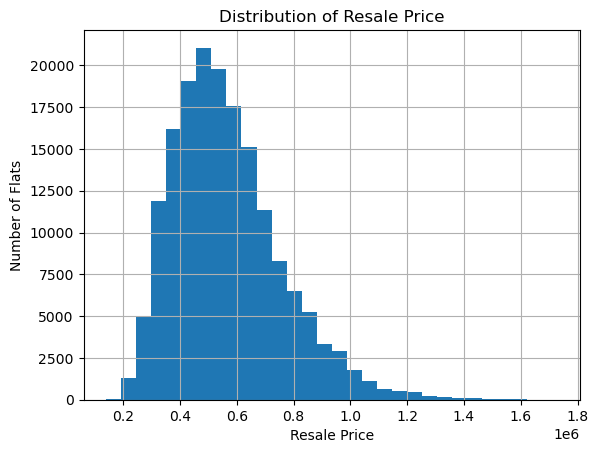

In [ ]:
## Understanding distribution of target
## Target variable
col_y = 'resale_price'

## Plot distribution of target variable shown as a histogram
df[col_y].hist(bins=30)
plt.title('Distribution of Resale Price')
plt.xlabel('Resale Price')
plt.ylabel('Number of Flats')
plt.show()

## Interpretation:
## The resale price distribution is right-skewed, with most resale prices concentrated between approximately SGD 400,000 and SGD 700,000
## There are fewer expensive flats above SGD 1 million, creating a long right tail in the distribution.

## Modelling implication:
## The dataset contains high-value properties that may be harder to predict, but the distribution is still suitable for regression modelling

### 2.3.1.2 Understanding distribution of features

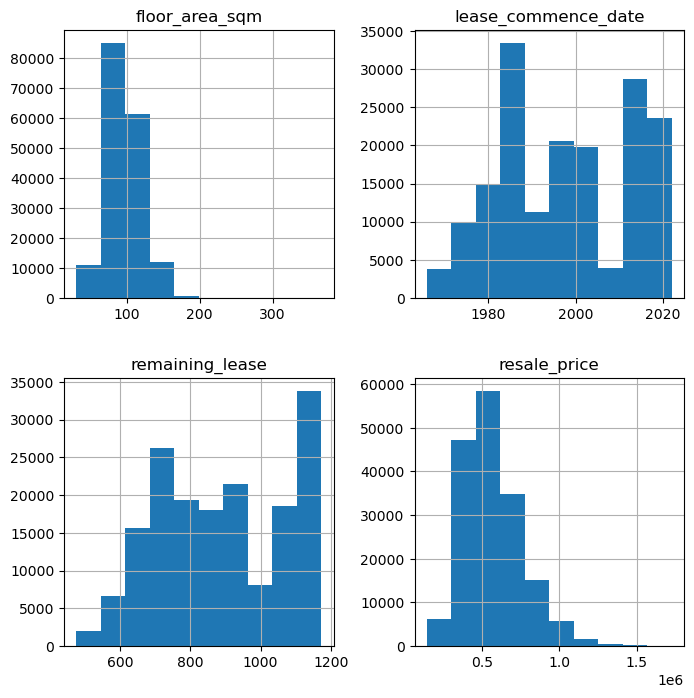

In [ ]:
## Understanding distribution of features
## Plot distributions of all numeric features
df.hist(figsize=(8,8))
plt.show()


## Interpretation:
## floor_area_sqm is heavily right-skewed, with most flats clustered between 60-100 sqm and a long thin tail beyond 200 sqm
## lease_commence_date is multi-modal, with distinct construction waves visible around the early 1980s, mid-1990s, and 2015-2020
## remaining_lease mirrors the shape of lease_commence_date (as expected, since it's derived from it), with a similar multi-modal pattern and values concentrated toward longer remaining leases
## resale_price is right-skewed, with most transactions between 300k-600k and a long tail extending past 1.5M

## Modelling implication:
## The skew may pull linear models toward outliers; log-transforming or capping extreme values could help, though tree-based models like Random Forest are less sensitive to this
## A non-linear/tree-based model is better suited to capture these distinct construction eras than a simple linear relationship
## Suggests that there might be a redundancy between remaining_lease and lease_commence_date
## Log-transforming resale_price (the target variable) may help reduce the influence of high-price outliers and improve model performance

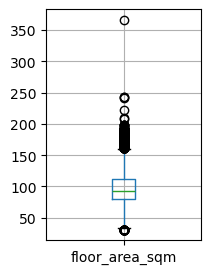

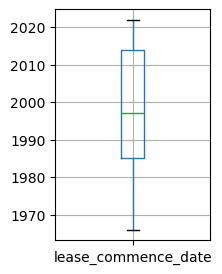

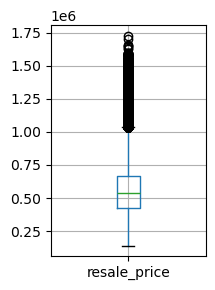

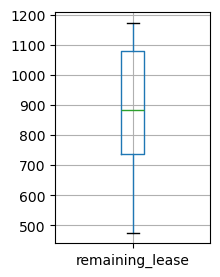

In [ ]:
## Boxplot to detect outliers features only (different scale from price)
df[['floor_area_sqm']].boxplot(figsize=(2,3))
plt.show()

## Interpretation:
## Several large floor area values appear as outliers. These likely represent executive flats or jumbo flats

## Modelling implication:
## The outliers were retained because they are genuine HDB property records rather than data entry errors. Tree-based models such as Random Forest are generally robust to outliers

df[['lease_commence_date']].boxplot(figsize=(2,3))
plt.show()

## Interpretation:
## Lease commencement dates are fairly well distributed with no significant abnormal outliers

## Modelling implication:
## The feature was retained because newer flats generally command higher resale prices due to longer remaining leases

df[['resale_price']].boxplot(figsize=(2,3))
plt.show()

## Interpretation:
## The resale price contains several high-value outliers above SGD 1 million. These correspond to premium HDB flats in desirable locations

## Modelling implication:
## The outliers were retained because they represent valid market transactions and improve the model's ability to predict expensive properties

df[['remaining_lease']].boxplot(figsize=(2,3))
plt.show()

## Interpretation:
## remaining_lease ranges roughly from 450 to 1175 (likely months), with a median around 880. The distribution is fairly symmetric with no extreme outliers, unlike floor_area_sqm or resale_price

## Modelling implication:
## The feature was retained for now, but it is highly correlated with lease_commence_date (near-duplicate information), so one of the two should be dropped before modelling to avoid redundancy

### 2.3.2 Understanding relationship between variables

                     floor_area_sqm  lease_commence_date  remaining_lease  \
floor_area_sqm             1.000000             0.061925         0.068639   
lease_commence_date        0.061925             1.000000         0.992393   
remaining_lease            0.068639             0.992393         1.000000   
resale_price               0.595320             0.363123         0.320265   

                     resale_price  
floor_area_sqm           0.595320  
lease_commence_date      0.363123  
remaining_lease          0.320265  
resale_price             1.000000  


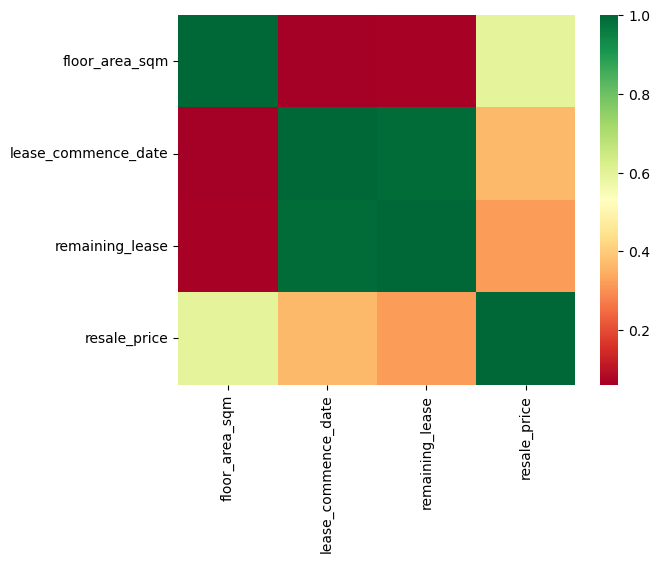

In [ ]:
## Understanding relationship between variables via heatmap
## Select numeric columns (hint: float/int types)
col_numeric = df.select_dtypes(include=['float64', 'int64']).columns

## Compute correlation matrix (relationship between numeric variables)
df_corr = df[col_numeric].corr()
print(df_corr)

## Visualization of correlation matrix using heatmap
sns.heatmap(df_corr, cmap='RdYlGn')
plt.show()

## Interpretation:
## Floor area has the strongest positive correlation with resale price (approximately 0.60), indicating that larger flats generally sell for higher prices
## Lease commencement date also has a positive relationship with resale price (approximately 0.36), suggesting newer flats tend to have higher resale values
## remaining_lease is almost perfectly correlated with lease_commence_date (~1.0), and shows a similar moderate correlation with resale_price (~0.4-0.5) as lease_commence_date does

## Modelling implication:
## Floor area and lease commencement date were retained as important predictors for the regression model. remaining_lease was flagged as redundant with lease_commence_date, so only one of the two should be kept

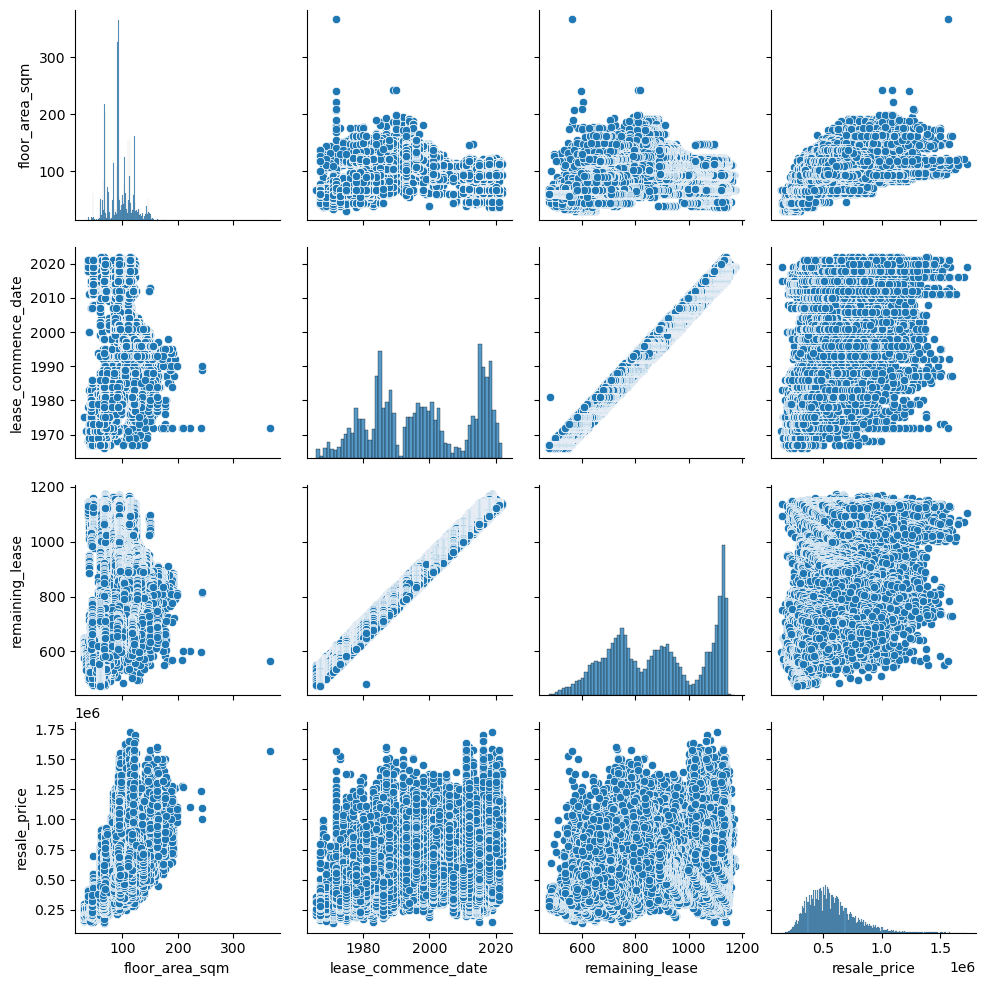

In [ ]:
## Pairwise relationships between variables
sns.pairplot(df)
plt.show()

## floor_area_sqm (distribution)
## Interpretation:
## floor_area_sqm is right-skewed with a few large outliers (>300 sqm)
## Modelling implication:
## Consider capping outliers or log-transforming floor_area_sqm

## lease_commence_date (distribution)
## Interpretation:
## lease_commence_date is multi-modal, with construction peaks in the late 1980s and mid-2010s
## Modelling implication:
## Treat as categorical/era-based, or derive flat_age instead

## remaining_lease (distribution)
## Interpretation:
## remaining_lease shows a similar multi-modal shape to lease_commence_date, as it is directly derived from it
## Modelling implication:
## Confirms redundancy with lease_commence_date; only one of the two should be kept in the model

## resale_price (distribution)
## Interpretation:
## resale_price is right-skewed, with a long tail above 1.5M
## Modelling implication:
## Log-transforming resale_price may improve model performance

## floor_area_sqm vs resale_price
## Interpretation:
## floor_area_sqm has a clear positive relationship with resale_price.
## Modelling implication:
## Supports including floor_area_sqm as a strong predictor

## lease_commence_date vs resale_price
## Interpretation:
## Newer leases (post-2010) show a higher price ceiling than older ones
## Modelling implication:
## Supports including a lease/flat-age feature

## remaining_lease vs lease_commence_date
## Interpretation:
## The scatterplot forms a near-perfect straight line, confirming these two features carry almost identical information
## Modelling implication:
## One of remaining_lease or lease_commence_date should be dropped to avoid multicollinearity/redundant features

## remaining_lease vs resale_price
## Interpretation:
## Shows a similarly weak, noisy relationship as lease_commence_date vs resale_price
## Modelling implication:
## Reinforces that remaining_lease adds no additional signal beyond what lease_commence_date already provides

# 3. Data Preparation

## 3.1 Data Cleaning

In [ ]:
## Dropping irrelevant columns
col_irrelevant = ["town", "block", "street_name","remaining_lease", "month"] 
## Columns that contain either identifiers (e.g., block, street name) or contain information not useful for training and testing
df = df.drop(col_irrelevant, axis=1)
df

## 'town' is removed because it has already been grouped into the broader
## 'block' and 'street_name' are removed because they are unique identifiers and are unlikely to generalise well to unseen data
## 'remaining_lease' is removed because it overlaps with the information provided by 'lease_commence_date', reducing duplicate lease-related features
## 'month' is removed because only transactions from 2020 onwards are used, making the transaction month less relevant for this prediction task

,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,region
7,5 ROOM,10 TO 12,119.0,Improved,1974,820000.0,Central
8,5 ROOM,19 TO 21,119.0,Improved,1974,850000.0,Central
9,5 ROOM,10 TO 12,117.0,Improved,1974,790000.0,Central
10,5 ROOM,22 TO 24,114.0,Improved,1974,850000.0,Central
11,5 ROOM,22 TO 24,114.0,Improved,1974,938000.0,Central
...,...,...,...,...,...,...,...
234063,EXECUTIVE,10 TO 12,137.0,Premium Apartment,2001,688888.0,North
234064,EXECUTIVE,13 TO 15,137.0,Premium Apartment,2001,670000.0,North
234065,EXECUTIVE,07 TO 09,137.0,Premium Apartment,2001,688888.0,North
234066,EXECUTIVE,01 TO 03,131.0,Premium Apartment,2001,688000.0,North


In [65]:
## Separate features (X) and target (y)

X = df.drop(col_y, axis=1) 
y = df[col_y] 

In [66]:
## Convert categorical variables into numerical format (one-hot encoding)
## This one-hot encoding does not use drop_first so all categories are retained.
## This prevents feature mismatches when predicting on new/unseen data.
X = pd.get_dummies(
    X,
    columns=[
        "region",
        "flat_type",
        "flat_model",
        "storey_range"
    ]
)
X

,floor_area_sqm,lease_commence_date,region_Central,region_East,region_North,region_North-East,region_West,flat_type_1 ROOM,flat_type_2 ROOM,flat_type_3 ROOM,...,storey_range_22 TO 24,storey_range_25 TO 27,storey_range_28 TO 30,storey_range_31 TO 33,storey_range_34 TO 36,storey_range_37 TO 39,storey_range_40 TO 42,storey_range_43 TO 45,storey_range_46 TO 48,storey_range_49 TO 51
7,119.0,1974,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,119.0,1974,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,117.0,1974,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10,114.0,1974,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
11,114.0,1974,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234063,137.0,2001,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
234064,137.0,2001,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
234065,137.0,2001,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
234066,131.0,2001,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 3.2 Train-Test Split

In [67]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split
 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2026
)
 
print(X_train.shape)
print(X_test.shape)


(118868, 52)
(50944, 52)


# 4. Modelling

### 4.2 Train Model

In [68]:
## Initialise and train model
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
 
gbt = GradientBoostingRegressor()
rf = RandomForestRegressor()
model = DecisionTreeRegressor()
gbt.fit(X_train, y_train)
rf.fit(X_train, y_train)
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

# 5. Model Evaluation

In [69]:
## Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
y_pred = model.predict(X_test)
y_pred_gbt = gbt.predict(X_test)
y_pred_rf = rf.predict(X_test)

## Compare the performance of all trained regression models using:
## 1. Mean Absolute Error (MAE), Mean Squared Error (MSE)
## 2. Root Mean Squared Error (RMSE) and R² score
## What high and low values am I looking for?:
## Lower MAE, MSE and RMSE indicate smaller prediction errors
## A higher R² score indicates better predictive performance

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))
 
print("GBDT MAE:", mean_absolute_error(y_test, y_pred_gbt))
print("GBDT MSE:", mean_squared_error(y_test, y_pred_gbt))
print("GBDT RMSE:", root_mean_squared_error(y_test, y_pred_gbt))
print("GBDT R2:", r2_score(y_test, y_pred_gbt))
 
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF MSE:", mean_squared_error(y_test, y_pred_rf))
print("RF RMSE:", root_mean_squared_error(y_test, y_pred_rf))
print("RF R2:", r2_score(y_test, y_pred_rf))

## RF has the lowest, NAE, MSE, RMSE and has the highest R2 value, hence I will be using RF

MAE: 69631.63253250206
MSE: 8394503487.20848
RMSE: 91621.52305658578
R2: 0.7725193938555961
GBDT MAE: 71907.37049406105
GBDT MSE: 8970732595.578897
GBDT RMSE: 94713.95143049886
GBDT R2: 0.7569043015455039
RF MAE: 67838.83497307851
RF MSE: 7778458844.649564
RF RMSE: 88195.57157051346
RF R2: 0.7892134376325577


In [70]:
## Hyperparameter Tuning
## Randomized Search

from scipy.stats import randint, uniform

## Randomized Search is applied to the Random Forest model because it
## achieved the best baseline performance, making it the most suitable
## candidate for hyperparameter tuning.

## The range of hyperparameters to be randomly sampled.
param_dist_rf = {
    'n_estimators': randint(1, 5),                  ## Number of trees
    'criterion': ['squared_error', 'absolute_error'], ## Split criterion
    'max_depth': randint(1, 3),                    ## Maximum tree depth
    'min_samples_split': randint(2, 5),            ## Minimum samples required to split
    'max_features': ['sqrt', 'log2'],              ## Number of features considered at each split
    'max_samples': uniform(0.6, 0.4)               ## Randomly sample 60%–100% of the training data
}

from sklearn.model_selection import RandomizedSearchCV

## Performing Randomized Search with 5-fold cross-validation to identify a better combination of hyperparameters while reducing computation time.
rs_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_iter=10,
    n_jobs=-1
)

## Training the Randomized Search using the training dataset.
rs_rf.fit(X_train, y_train)

## Retrieving the best hyperparameter combination and the corresponding model.
best_fit_params = rs_rf.best_params_
best_rs_rf = rs_rf.best_estimator_

print("Best Parameters:", best_fit_params)
print("Best Estimator:", best_rs_rf)

## Evaluating the tuned Random Forest model using the test dataset.
y_pred_rs_rf = best_rs_rf.predict(X_test)

print("Tuned Random Forest MAE:", mean_absolute_error(y_test, y_pred_rs_rf))
print("Tuned Random Forest R2:", r2_score(y_test, y_pred_rs_rf))

Best Parameters: {'criterion': 'squared_error', 'max_depth': 2, 'max_features': 'sqrt', 'max_samples': np.float64(0.9864565427873998), 'min_samples_split': 4, 'n_estimators': 2}
Best Estimator: RandomForestRegressor(max_depth=2, max_features='sqrt',
                      max_samples=np.float64(0.9864565427873998),
                      min_samples_split=4, n_estimators=2)
Tuned Random Forest MAE: 119323.84505397463
Tuned Random Forest R2: 0.308036328658881


In [71]:
## Comparing the untuned RF vs tuned RF based on MAE to decide on a final model.
print("Untuned RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Tuned RF MAE:", mean_absolute_error(y_test, y_pred_rs_rf))

Untuned RF MAE: 67838.83497307851
Tuned RF MAE: 119323.84505397463


In [72]:
## Comparing the untuned RF vs tuned RF based on RMSE to decide on a final model.
print("Untuned RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Tuned RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rs_rf)))

Untuned RF RMSE: 88195.57157051346
Tuned RF RMSE: 159796.39066734197


In [73]:
## Comparing the untuned RF vs tuned RF based on R2 to decide on a final model.
print("Untuned RF R2:", r2_score(y_test, y_pred_rf))
print("Tuned RF R2:", r2_score(y_test, y_pred_rs_rf))

Untuned RF R2: 0.7892134376325577
Tuned RF R2: 0.308036328658881


In [74]:
## The untuned RF model achieved a substantially higher R² score, indicating it explained much more of the variance in resale prices than the tuned RF model
## The untuned RF model also produced a lower Mean Absolute Error, meaning its predictions were, on average, closer to the actual resale prices than the tuned RF model
## The lower RMSE further for untunned RF model indicates that the untuned RF model produced more accurate predictions while reducing the impact of larger prediction errors than the tuned RF model
## Hence, the final model will be rf
final_model = rf

## Iterative model development


In [75]:
## Feature Importance

## Retrieve the importance score assigned to each feature by the selected Random Forest model.
df_model_feat_impt = pd.DataFrame({
    'Feature': final_model.feature_names_in_,
    'Importance': final_model.feature_importances_
})

## Group one-hot encoded features back into their original feature names to make the results easier to interpret.
df_model_feat_impt['Feature'] = (
    df_model_feat_impt['Feature']
    .str.rsplit('_', n=1)
    .str[0]
)

## Sum the importance of one-hot encoded categories belonging to the same original feature and sort them.
df_model_feat_impt = (
    df_model_feat_impt
    .groupby('Feature')['Importance']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

## Calculate the cumulative importance contributed by the features.
df_model_feat_impt['Cumulative importance'] = (
    df_model_feat_impt['Importance'].cumsum()
)

df_model_feat_impt

## Feature importance table
## Interpretation:
## The final model relies most heavily on floor_area (0.53), followed by region (0.21) and lease_commence (0.17), together explaining over 90% of its predictions. storey_range, flat_model and flat_type play only a minor role in how the model determines resale price.

,Feature,Importance,Cumulative importance
0,floor_area,0.527324,0.527324
1,region,0.204905,0.732229
2,lease_commence,0.171421,0.903650
3,storey_range,0.049043,0.952693
4,flat_model,0.026362,0.979055
5,flat_type,0.020945,1.000000


C:\Users\dtsli\AppData\Local\Temp\ipykernel_51392\1346086354.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(


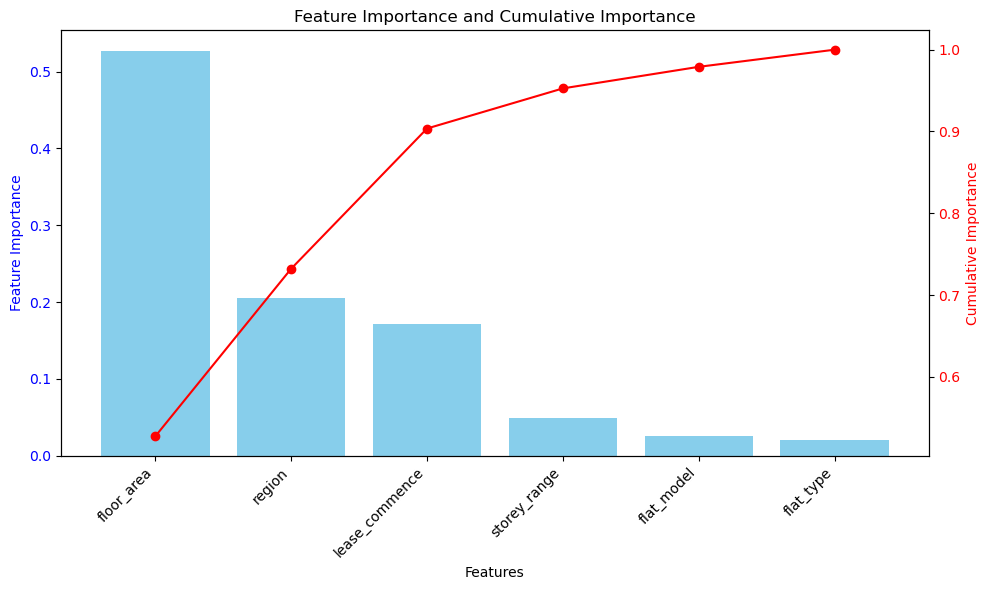

In [76]:
## Visualization of feature importance and cumulative importance to identify which features contribute the most to the prediction.

fig, ax1 = plt.subplots(figsize=(10, 6))

## Display feature importance using a bar chart.
ax1.bar(
    df_model_feat_impt['Feature'],
    df_model_feat_impt['Importance'],
    color='skyblue'
)

ax1.set_xlabel('Features')
ax1.set_ylabel('Feature Importance', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(
    df_model_feat_impt['Feature'],
    rotation=45,
    ha='right'
)

## Display cumulative feature importance using a line chart.
ax2 = ax1.twinx()
ax2.plot(
    df_model_feat_impt['Feature'],
    df_model_feat_impt['Cumulative importance'],
    color='red',
    marker='o'
)

ax2.set_ylabel('Cumulative Importance', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Feature Importance and Cumulative Importance')
plt.tight_layout()
plt.show()

## Feature importance and cumulative importance chart
## Interpretation:
## The steep rise in the cumulative importance curve confirms that the model's predictions are dominated by just three features: floor_area, region, and lease_commence while the remaining features add only marginal, incremental information.

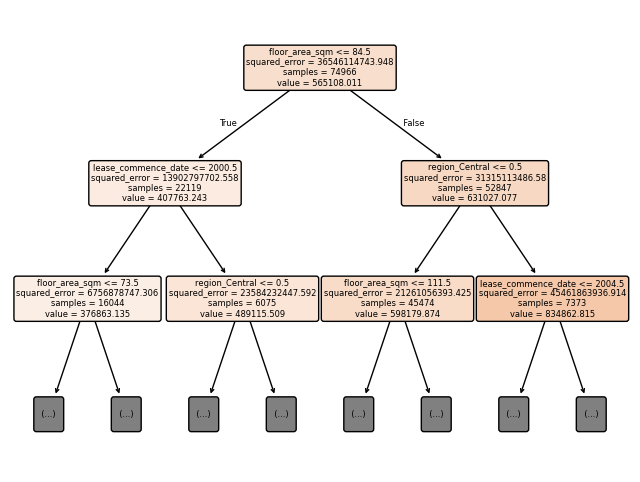

In [77]:
## Visualise one decision tree from the Random Forest model to understand how predictions are made.

from sklearn.tree import plot_tree

plt.figure(figsize=(8, 6))

plot_tree(
    final_model.estimators_[0],
    feature_names=final_model.feature_names_in_,
    max_depth=2,
    filled=True,
    rounded=True,
    fontsize=6
)

plt.show()


## Sample decision tree (max_depth=2)
## Interpretation:
## This shows one shallow tree from the Random Forest (truncated to depth 2 for better visualisation). It first splits on floor_area_sqm (<= 84.5), then on lease_commence_date and region_Central which is consistent with the top 3 features from the importance ranking.
## The predicted values reflect this: smaller, older flats (floor_area <= 84.5 and lease_commence <= 1997) average ~$377,730, while larger, newer, centrally-located flats (floor_area > 84.5 and lease_commence > 2004.5) average ~$830,211 which is more than double. 
## This illustrates the compounding effect of size, age, and location on predicted resale price.

In [78]:
## Model export for deployment
import joblib
joblib.dump(final_model, "hdb_final_model.pkl", compress = 3) ## Compression is used to reduce the file size for GitHub.


['hdb_final_model.pkl']